# 과수원 내 로봇 주행 데이터(사과, 배 류) — EDA
https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71700
<br>
<br>
[AI Hub 데이터셋](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71700) **과수원 내 로봇 주행 데이터(사과, 배 류)** 샘플의 탐색적 데이터 분석(EDA)입니다.

사과·배 과수원의 농로·노지에서 취득한 RGB 이미지와 LiDAR 포인트클라우드로, 자율주행 경로 식별 및 객체 탐지 학습에 사용합니다.

| 항목 | 내용 |
|------|------|
| 데이터 | 사과(AP) / 배(PE) 과수원 로봇 주행 RGB + PCD 샘플 |
| 구성 | JPG 630장 + PCD 390개 + JSON 1,020개 |
| 라벨 | BBX(바운딩박스) 510 · CUB(3D 큐보이드) 390 · SEG(세그멘테이션) 120 |
| 클래스 | 사람, 손수레, 운반차, 트럭, 방제기, 사다리, 과수박스, 창고, 사과, 배_봉지, 비포장, 기타, 사과나무, 배나무 |
| 해상도 | FHD 1920×1080 |
| 목적 | 과수원 자율주행·객체 탐지 전 YOLO 학습용 데이터 이해 |

<br>

> 구축 목적: 수확·이송·방제 등 농작업 서비스 로봇의 경로 식별 및 장애물·작물 탐지

## 0. 환경 설정

In [1]:
import json
import re
import shutil
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 프로젝트 루트 (노트북·데이터 폴더가 있는 위치) ──
DATA_DIR_NAME = "과수원 내 로봇 주행 데이터(사과, 배 류)"
ZIP_CANDIDATES = [
    DATA_DIR_NAME + ".zip",
    "orchard_robot.zip",
]
RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"

CROP_MAP = {"AP": "사과", "PE": "배"}
PLATFORM_MAP = {"HR": "HR", "TP": "TP", "PC": "PC"}

FILE_PAT = re.compile(
    r"^(?P<crop>AP|PE)_(?P<farm>\d{3})_(?P<platform>[A-Z]{2})_"
    r"(?P<date>\d{8})_(?P<ampm>AM|PM)_"
    r"(?P<c1>\d{3})_(?P<c2>\d{3})_(?P<c3>\d{3})_(?P<frame>\d{4})"
)

CLASS_COLORS = {
    "사람": "#E74C3C",
    "손수레": "#E67E22",
    "운반차": "#F39C12",
    "트럭": "#8E44AD",
    "방제기": "#3498DB",
    "사다리": "#1ABC9C",
    "과수박스": "#27AE60",
    "창고": "#7F8C8D",
    "사과": "#C0392B",
    "배_봉지": "#F1C40F",
    "비포장": "#95A5A6",
    "기타": "#BDC3C7",
    "사과나무": "#196F3D",
    "배나무": "#52BE80",
}


def find_root() -> Path:
    cwd = Path.cwd()
    for base in [cwd, *cwd.parents]:
        if (base / DATA_DIR_NAME).exists():
            return base
        if (base / RAW_DIR_NAME).exists() and (base / LABEL_DIR_NAME).exists():
            return base
        for zname in ZIP_CANDIDATES:
            if (base / zname).exists():
                return base
    return cwd


ROOT = find_root()
ZIP_PATH = next((ROOT / z for z in ZIP_CANDIDATES if (ROOT / z).exists()), ROOT / ZIP_CANDIDATES[0])
DATA_ROOT = ROOT / DATA_DIR_NAME if (ROOT / DATA_DIR_NAME).exists() else ROOT
EDA_OUT = DATA_ROOT / "eda"


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    jpgs = [p for p in root.rglob("*.jpg") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(jpgs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    """AI Hub zip — CP949 파일명으로 압축 해제 (한글 폴더명 깨짐 방지)."""
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.jpg")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


print(f"ROOT      : {ROOT.resolve()}")
print(f"DATA_ROOT : {DATA_ROOT.resolve()}")
print(f"ZIP 존재  : {ZIP_PATH.exists()}")
print(f"데이터 준비: {data_is_ready(DATA_ROOT)}")
print(f"한글 경로 : {has_correct_korean_paths(DATA_ROOT)}")

ROOT      : C:\MyCursorLab\08_Object_Detection
DATA_ROOT : C:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)
ZIP 존재  : True
데이터 준비: True
한글 경로 : True


## 1. 데이터 경로 및 폴더 구조

In [2]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT):
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"데이터 폴더 또는 zip이 없습니다.\n"
            f"  폴더: {DATA_ROOT}\n"
            f"  zip : {ZIP_PATH}"
        )
    extract_zip(ZIP_PATH, DATA_ROOT, force=True)
    print("압축 해제 완료 (CP949 인코딩 적용)")
else:
    print("데이터 폴더 사용 (이미 압축 해제됨)")

EDA_OUT.mkdir(parents=True, exist_ok=True)
raw_root, label_root = find_raw_and_label_roots(DATA_ROOT)

n_jpg = len(list(raw_root.rglob("*.jpg")))
n_pcd = len(list(raw_root.rglob("*.pcd")))
n_json = len(list(label_root.rglob("*.json")))
n_bbx = len(list(label_root.rglob("*_BBX.json")))
n_cub = len(list(label_root.rglob("*_CUB.json")))
n_seg = len(list(label_root.rglob("*_SEG.json")))

print(f"원본 데이터 : {raw_root.name}")
print(f"  JPG  : {n_jpg}장")
print(f"  PCD  : {n_pcd}개")
print(f"라벨 데이터 : {label_root.name}")
print(f"  JSON : {n_json}개  (BBX {n_bbx} / CUB {n_cub} / SEG {n_seg})")
print()

# 작물별 시퀀스 요약
for crop_dir in sorted(p for p in raw_root.iterdir() if p.is_dir()):
    seqs = [s for s in crop_dir.iterdir() if s.is_dir()]
    print(f"[{crop_dir.name}] 시퀀스 {len(seqs)}개")
    for seq in seqs:
        n_img = len(list((seq / "IMG").glob("*.jpg"))) if (seq / "IMG").exists() else 0
        n_cloud = len(list((seq / "PCD").glob("*.pcd"))) if (seq / "PCD").exists() else 0
        kinds = []
        lab_seq = label_root / crop_dir.name / seq.name
        if lab_seq.exists():
            kinds = [d.name for d in sorted(lab_seq.iterdir()) if d.is_dir()]
        print(f"  {seq.name}  img={n_img:3d}  pcd={n_cloud:3d}  labels={kinds}")

데이터 폴더 사용 (이미 압축 해제됨)
원본 데이터 : 01.원천데이터
  JPG  : 630장
  PCD  : 390개
라벨 데이터 : 02.라벨링데이터
  JSON : 1020개  (BBX 510 / CUB 390 / SEG 120)

[배] 시퀀스 11개
  PE_001_HR_20231006_PM_000_000_000  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_HR_20231010_PM_000_000_000  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_HR_20231020_PM_000_001_002  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_HR_20231024_AM_000_000_001  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_HR_20231111_AM_000_000_000  img= 30  pcd=  0  labels=['SEG']
  PE_001_HR_20231120_PM_001_000_000  img= 30  pcd=  0  labels=['SEG']
  PE_001_PC_20231114_AM_000_000_000  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_PC_20231114_PM_001_002_002  img= 30  pcd=  0  labels=['BBX']
  PE_001_TP_20231021_AM_000_002_003  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_TP_20231109_PM_000_002_006  img= 30  pcd= 30  labels=['BBX', 'CUB']
  PE_001_TP_20231110_PM_001_006_002  img= 30  pcd=  0  labels=['BBX']
[사과] 시퀀스 10개
  AP_001_HR_20230927_A

## 2. 메타데이터 수집

파일명 규칙:

`{작물}_{농장}_{플랫폼}_{YYYYMMDD}_{AMPM}_{c1}_{c2}_{c3}_{프레임}_{타입}`

| 토큰 | 예시 | 의미 |
|------|------|------|
| 작물 | `AP` / `PE` | 사과 / 배 |
| 농장 | `001` | 과수원(사이트) ID |
| 플랫폼 | `HR` / `TP` / `PC` | 주행 플랫폼·센서 구분 코드 |
| 시각 | `AM` / `PM` | 오전 / 오후 |
| 타입 | `IMG` / `BBX` / `CUB` / `SEG` | 원천 이미지 / 2D박스 / 3D큐보이드 / 세그멘테이션 |

BBX·SEG는 COCO 유사 JSON (`categories` / `images` / `annotations`), CUB는 3D 큐보이드(`position`, `rotation`, `scale`)입니다.

In [3]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8-sig"))


def parse_stem_meta(stem: str) -> dict:
    m = FILE_PAT.match(stem.replace("_IMG", "").replace("_BBX", "").replace("_CUB", "").replace("_SEG", ""))
    if not m:
        return {"crop_code": None, "crop": None, "farm": None, "platform": None,
                "date": None, "ampm": None, "frame": None}
    g = m.groupdict()
    return {
        "crop_code": g["crop"],
        "crop": CROP_MAP.get(g["crop"], g["crop"]),
        "farm": g["farm"],
        "platform": g["platform"],
        "date": g["date"],
        "ampm": g["ampm"],
        "frame": int(g["frame"]),
        "c1": g["c1"],
        "c2": g["c2"],
        "c3": g["c3"],
    }


def json_to_image_path(json_path: Path) -> Path | None:
    rel_seq = json_path.parent.parent.relative_to(label_root)  # {작물}/{시퀀스}
    data = load_json(json_path)
    kind = json_path.parent.name
    if kind in ("BBX", "SEG"):
        file_name = data["images"][0]["file_name"]
    else:
        item_id = data["items"][0]["id"]
        file_name = item_id if item_id.endswith(".jpg") else f"{item_id}.jpg"
        if not file_name.endswith("_IMG.jpg") and "_IMG" not in file_name:
            file_name = file_name.replace(".jpg", "_IMG.jpg")
    img_path = raw_root / rel_seq / "IMG" / file_name
    return img_path if img_path.exists() else None


def iter_bbx_seg_anns(data: dict):
    cats = {c["id"]: c["name"] for c in data.get("categories", [])}
    for ann in data.get("annotations", []):
        yield {
            "class_name": cats.get(ann["category_id"], str(ann.get("category_id"))),
            "category_id": ann.get("category_id"),
            "bbox": ann.get("bbox"),
            "area": ann.get("area"),
            "segmentation": ann.get("segmentation") or [],
            "occluded": (ann.get("attributes") or {}).get("occluded"),
        }


def iter_cub_anns(data: dict):
    labels = data.get("categories", {}).get("label", {}).get("labels", [])
    for item in data.get("items", []):
        for ann in item.get("annotations", []):
            lid = ann.get("label_id")
            name = labels[lid]["name"] if isinstance(lid, int) and 0 <= lid < len(labels) else str(lid)
            scale = ann.get("scale") or [None, None, None]
            pos = ann.get("position") or [None, None, None]
            yield {
                "class_name": name,
                "position": pos,
                "scale": scale,
                "occluded": (ann.get("attributes") or {}).get("occluded"),
            }


image_rows, ann_rows, cub_rows = [], [], []

for json_path in sorted(label_root.rglob("*.json")):
    kind = json_path.parent.name
    crop_folder = json_path.parent.parent.parent.name
    seq_name = json_path.parent.parent.name
    data = load_json(json_path)
    stem_meta = parse_stem_meta(json_path.stem)

    if kind in ("BBX", "SEG"):
        img_info = data["images"][0]
        anns = list(iter_bbx_seg_anns(data))
        bbox_areas = []
        for ann in anns:
            bbox = ann["bbox"]
            if bbox and len(bbox) == 4:
                area = bbox[2] * bbox[3]
                bbox_areas.append(area)
                ann_rows.append({
                    **stem_meta,
                    "kind": kind,
                    "crop_folder": crop_folder,
                    "sequence": seq_name,
                    "file_name": img_info["file_name"],
                    "class_name": ann["class_name"],
                    "bbox_w": bbox[2],
                    "bbox_h": bbox[3],
                    "bbox_area": area,
                    "rel_area": area / (img_info["width"] * img_info["height"]),
                    "occluded": ann["occluded"],
                    "json_path": str(json_path),
                })
        image_rows.append({
            **stem_meta,
            "kind": kind,
            "crop_folder": crop_folder,
            "sequence": seq_name,
            "file_name": img_info["file_name"],
            "width": img_info["width"],
            "height": img_info["height"],
            "num_annotations": len(anns),
            "avg_bbox_area": float(np.mean(bbox_areas)) if bbox_areas else 0.0,
            "json_path": str(json_path),
        })
    elif kind == "CUB":
        anns = list(iter_cub_anns(data))
        for ann in anns:
            sx, sy, sz = ann["scale"]
            cub_rows.append({
                **stem_meta,
                "kind": "CUB",
                "crop_folder": crop_folder,
                "sequence": seq_name,
                "class_name": ann["class_name"],
                "scale_x": sx,
                "scale_y": sy,
                "scale_z": sz,
                "occluded": ann["occluded"],
                "json_path": str(json_path),
            })
        image_rows.append({
            **stem_meta,
            "kind": "CUB",
            "crop_folder": crop_folder,
            "sequence": seq_name,
            "file_name": json_path.stem.replace("_CUB", "_IMG.jpg"),
            "width": None,
            "height": None,
            "num_annotations": len(anns),
            "avg_bbox_area": None,
            "json_path": str(json_path),
        })

df_img = pd.DataFrame(image_rows)
df_ann = pd.DataFrame(ann_rows)
df_cub = pd.DataFrame(cub_rows)
df_bbx = df_img[df_img["kind"] == "BBX"].copy()
df_seg = df_img[df_img["kind"] == "SEG"].copy()

print(f"이미지 레코드 : {len(df_img)}  (BBX {len(df_bbx)}, SEG {len(df_seg)}, CUB {(df_img.kind=='CUB').sum()})")
print(f"2D 객체      : {len(df_ann)}  (BBX {(df_ann.kind=='BBX').sum()}, SEG {(df_ann.kind=='SEG').sum()})")
print(f"3D 큐보이드  : {len(df_cub)}")
display(df_bbx.head())

이미지 레코드 : 1020  (BBX 510, SEG 120, CUB 390)
2D 객체      : 1598  (BBX 1418, SEG 180)
3D 큐보이드  : 565


,crop_code,crop,farm,platform,date,ampm,frame,c1,c2,c3,kind,crop_folder,sequence,file_name,width,height,num_annotations,avg_bbox_area,json_path
0,PE,배,001,HR,20231006,PM,71,000,000,000,BBX,배,PE_001_HR_20231006_PM_000_000_000,PE_001_HR_20231006_PM_000_000_000_0071_IMG.jpg,1920.0,1080.0,1,700920.0,c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행...
1,PE,배,001,HR,20231006,PM,72,000,000,000,BBX,배,PE_001_HR_20231006_PM_000_000_000,PE_001_HR_20231006_PM_000_000_000_0072_IMG.jpg,1920.0,1080.0,1,600158.0,c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행...
2,PE,배,001,HR,20231006,PM,73,000,000,000,BBX,배,PE_001_HR_20231006_PM_000_000_000,PE_001_HR_20231006_PM_000_000_000_0073_IMG.jpg,1920.0,1080.0,1,505730.0,c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행...
3,PE,배,001,HR,20231006,PM,74,000,000,000,BBX,배,PE_001_HR_20231006_PM_000_000_000,PE_001_HR_20231006_PM_000_000_000_0074_IMG.jpg,1920.0,1080.0,1,425015.0,c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행...
4,PE,배,001,HR,20231006,PM,75,000,000,000,BBX,배,PE_001_HR_20231006_PM_000_000_000,PE_001_HR_20231006_PM_000_000_000_0075_IMG.jpg,1920.0,1080.0,1,451527.5,c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행...


## 3. 분포 시각화

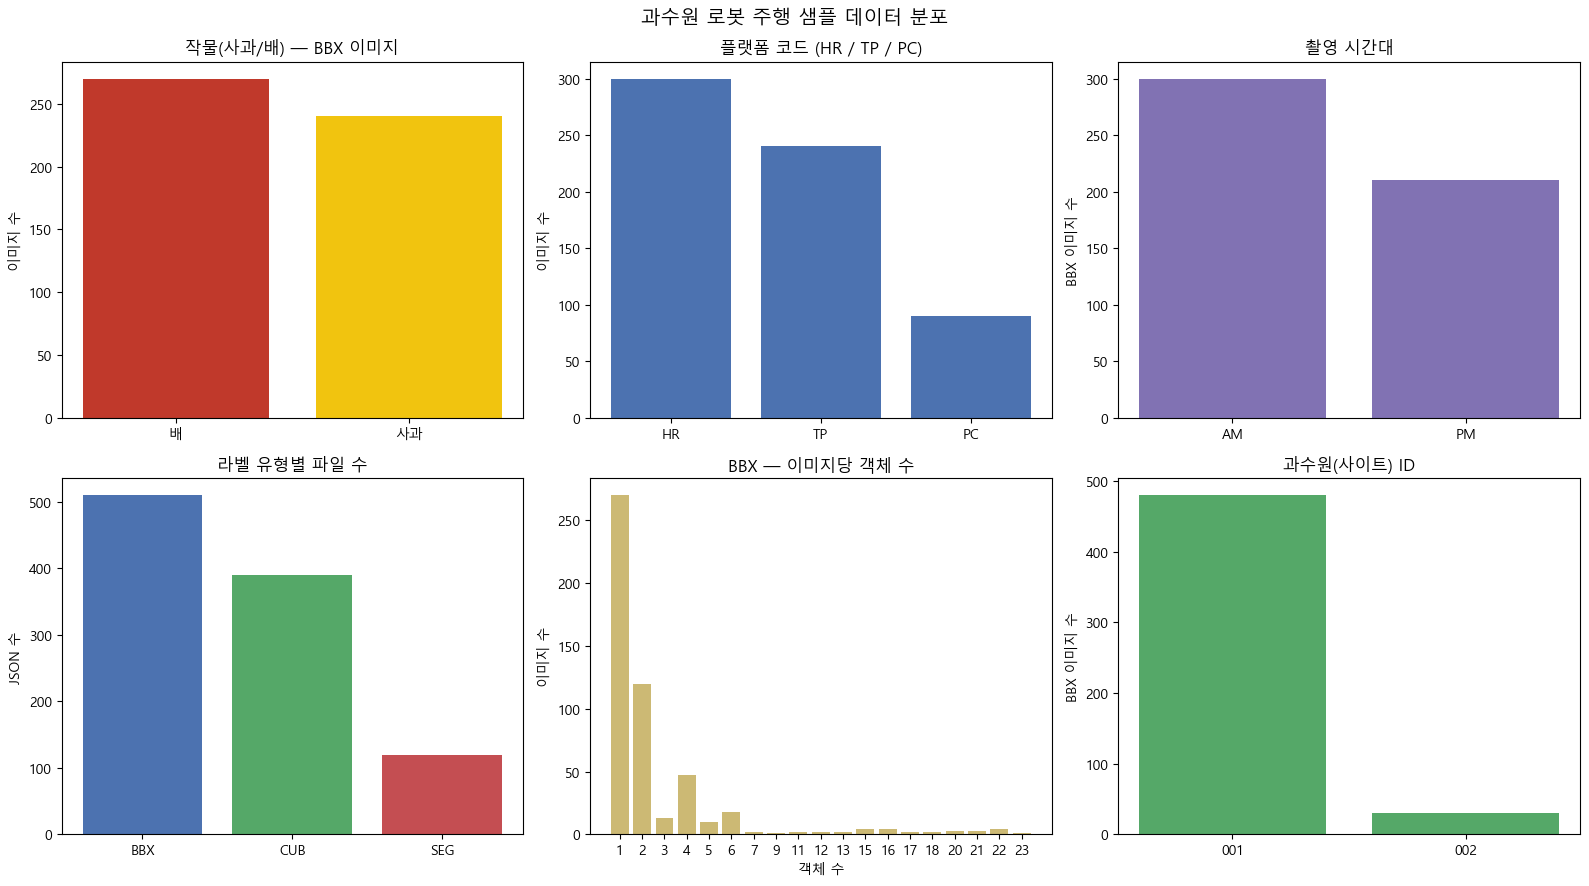

저장: c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)\eda\distribution_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("과수원 로봇 주행 샘플 데이터 분포", fontsize=14)

crop_cnt = df_bbx["crop"].value_counts()
axes[0, 0].bar(crop_cnt.index.astype(str), crop_cnt.values, color=["#C0392B", "#F1C40F"][: len(crop_cnt)])
axes[0, 0].set_title("작물(사과/배) — BBX 이미지")
axes[0, 0].set_ylabel("이미지 수")

plat_cnt = df_img[df_img["kind"] != "CUB"]["platform"].value_counts()
axes[0, 1].bar(plat_cnt.index.astype(str), plat_cnt.values, color="#4C72B0")
axes[0, 1].set_title("플랫폼 코드 (HR / TP / PC)")
axes[0, 1].set_ylabel("이미지 수")

ampm_cnt = df_bbx["ampm"].value_counts().reindex(["AM", "PM"]).dropna()
axes[0, 2].bar(ampm_cnt.index.astype(str), ampm_cnt.values, color="#8172B3")
axes[0, 2].set_title("촬영 시간대")
axes[0, 2].set_ylabel("BBX 이미지 수")

kind_cnt = pd.Series({"BBX": n_bbx, "CUB": n_cub, "SEG": n_seg})
axes[1, 0].bar(kind_cnt.index, kind_cnt.values, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1, 0].set_title("라벨 유형별 파일 수")
axes[1, 0].set_ylabel("JSON 수")

ann_cnt = df_bbx["num_annotations"].value_counts().sort_index()
axes[1, 1].bar(ann_cnt.index.astype(str), ann_cnt.values, color="#CCB974")
axes[1, 1].set_title("BBX — 이미지당 객체 수")
axes[1, 1].set_xlabel("객체 수")
axes[1, 1].set_ylabel("이미지 수")

farm_cnt = df_bbx["farm"].value_counts().sort_index()
axes[1, 2].bar(farm_cnt.index.astype(str), farm_cnt.values, color="#55A868")
axes[1, 2].set_title("과수원(사이트) ID")
axes[1, 2].set_ylabel("BBX 이미지 수")

plt.tight_layout()
out_path = EDA_OUT / "distribution_overview.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"저장: {out_path}")

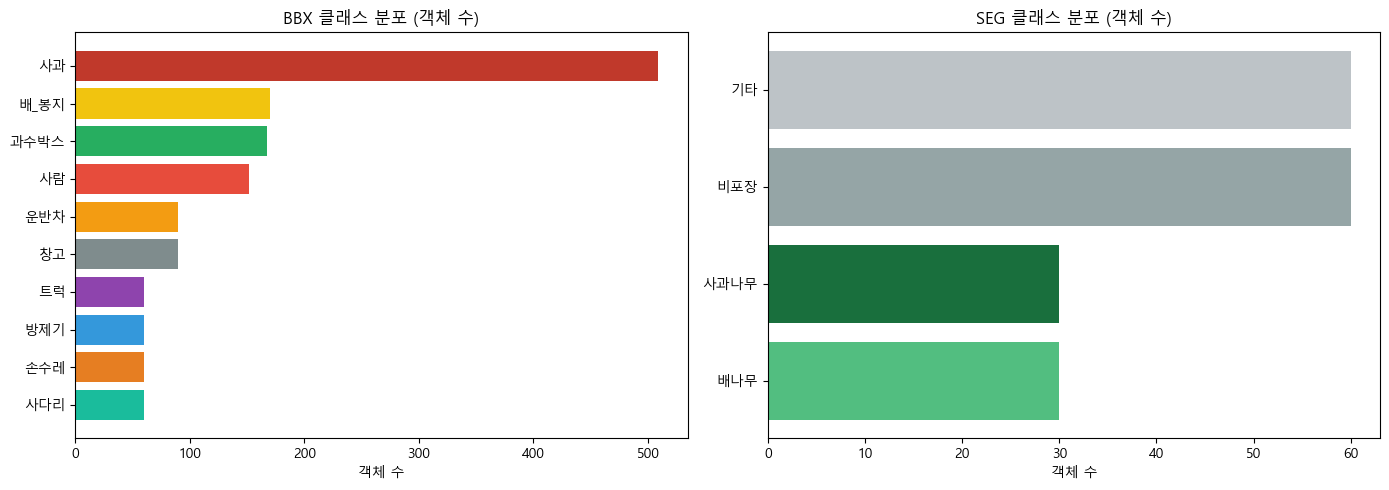

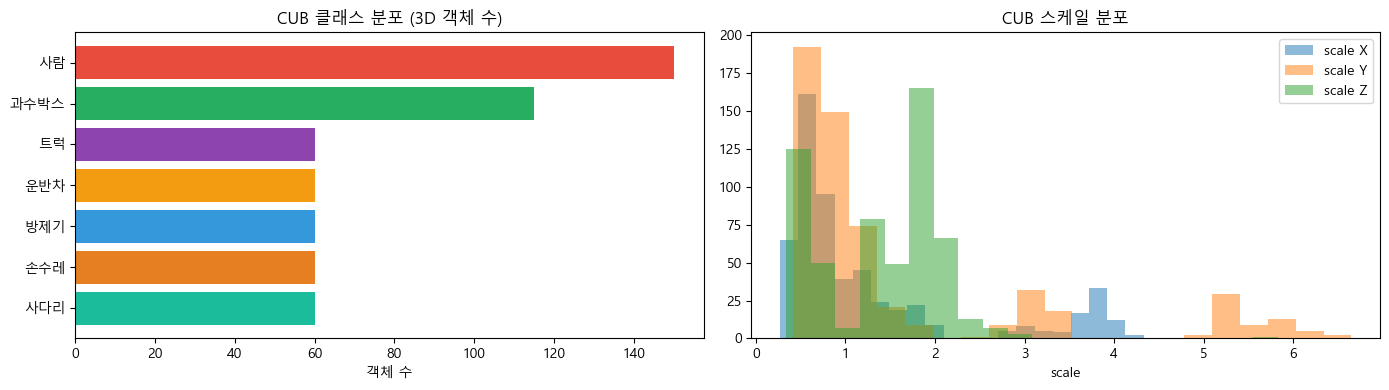

BBX 클래스: {'사과': 509, '배_봉지': 170, '과수박스': 167, '사람': 152, '창고': 90, '운반차': 90, '사다리': 60, '손수레': 60, '방제기': 60, '트럭': 60}
SEG 클래스: {'비포장': 60, '기타': 60, '배나무': 30, '사과나무': 30}
CUB 클래스: {'사람': 150, '과수박스': 115, '사다리': 60, '손수레': 60, '방제기': 60, '운반차': 60, '트럭': 60}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bbx_cls = df_ann[df_ann["kind"] == "BBX"]["class_name"].value_counts().sort_values()
colors = [CLASS_COLORS.get(n, "#4C72B0") for n in bbx_cls.index]
axes[0].barh(bbx_cls.index, bbx_cls.values, color=colors)
axes[0].set_title("BBX 클래스 분포 (객체 수)")
axes[0].set_xlabel("객체 수")

seg_cls = df_ann[df_ann["kind"] == "SEG"]["class_name"].value_counts().sort_values()
if len(seg_cls):
    colors = [CLASS_COLORS.get(n, "#4C72B0") for n in seg_cls.index]
    axes[1].barh(seg_cls.index, seg_cls.values, color=colors)
axes[1].set_title("SEG 클래스 분포 (객체 수)")
axes[1].set_xlabel("객체 수")

plt.tight_layout()
plt.savefig(EDA_OUT / "class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

if len(df_cub):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    cub_cls = df_cub["class_name"].value_counts().sort_values()
    colors = [CLASS_COLORS.get(n, "#4C72B0") for n in cub_cls.index]
    axes[0].barh(cub_cls.index, cub_cls.values, color=colors)
    axes[0].set_title("CUB 클래스 분포 (3D 객체 수)")
    axes[0].set_xlabel("객체 수")

    for col, label in (("scale_x", "X"), ("scale_y", "Y"), ("scale_z", "Z")):
        axes[1].hist(df_cub[col].dropna(), bins=20, alpha=0.5, label=f"scale {label}")
    axes[1].set_title("CUB 스케일 분포")
    axes[1].set_xlabel("scale")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(EDA_OUT / "cuboid_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()

print("BBX 클래스:", df_ann[df_ann.kind == "BBX"]["class_name"].value_counts().to_dict())
print("SEG 클래스:", df_ann[df_ann.kind == "SEG"]["class_name"].value_counts().to_dict())
print("CUB 클래스:", df_cub["class_name"].value_counts().to_dict() if len(df_cub) else {})

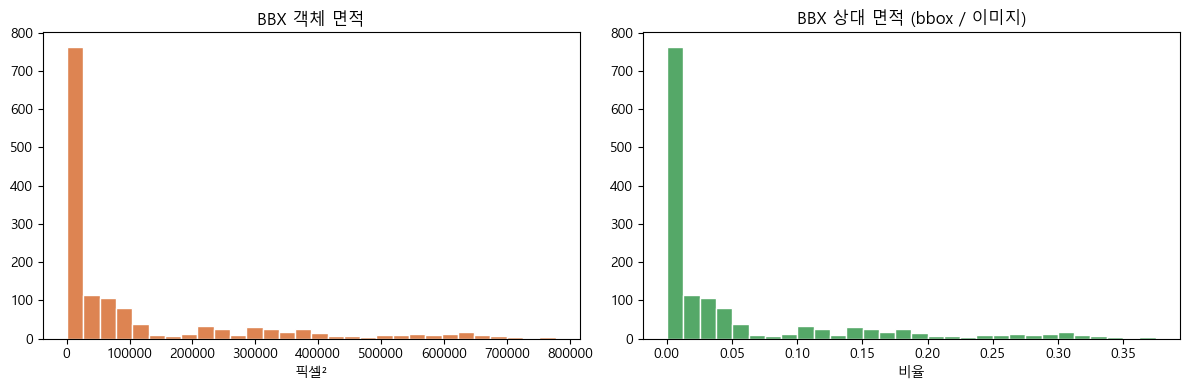

저장: c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)\eda\bbox_area_distribution.png


bbox_w                      bbox_h                   rel_area  \
                mean   median      max      mean   median      max     mean   
class_name                                                                    
과수박스        179.4412  193.810   312.80  123.6796  131.400   215.84   0.0128   
방제기         788.9055  714.185  1178.32  479.4850  471.640   651.60   0.1939   
배_봉지         55.2011   50.535   107.00   66.6274   59.150   161.41   0.0021   
사과           44.5507   42.690    77.33   41.9766   41.210    69.04   0.0009   
사다리         495.0390  486.535   603.78  707.9850  667.450   903.50   0.1676   
사람          246.2387  178.400   764.00  586.7958  461.465  1080.00   0.0874   
손수레         372.1860  383.085   428.39  247.3740  265.590   308.93   0.0451   
운반차         481.6076  391.730  1019.10  327.3388  218.000   683.00   0.0978   
창고          578.5019  494.325   998.40  434.6982  383.560   812.47   0.1182   
트럭          996.8693  963.680  1271.08  390.8423  369.490   521.04   0.1982   

                            
            median     max  
class_name                  
과수박스        0.0133  0.0308  
방제기         0.1649  0.3703  
배_봉지        0.0015  0.0082  
사과          0.0008  0.0024  
사다리         0.1644  0.2154  
사람          0.0402  0.3747  
손수레         0.0510  0.0600  
운반차         0.0410  0.3357  
창고          0.1458  0.2033  
트럭          0.1767  0.3179

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bbx_ann = df_ann[df_ann["kind"] == "BBX"]
axes[0].hist(bbx_ann["bbox_area"].dropna(), bins=30, color="#DD8452", edgecolor="white")
axes[0].set_title("BBX 객체 면적")
axes[0].set_xlabel("픽셀²")

axes[1].hist(bbx_ann["rel_area"].dropna(), bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("BBX 상대 면적 (bbox / 이미지)")
axes[1].set_xlabel("비율")

plt.tight_layout()
out_path = EDA_OUT / "bbox_area_distribution.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"저장: {out_path}")
display(bbx_ann.groupby("class_name")[["bbox_w", "bbox_h", "rel_area"]].agg(["mean", "median", "max"]).round(4))

## 4. 샘플 이미지 + 라벨 시각화

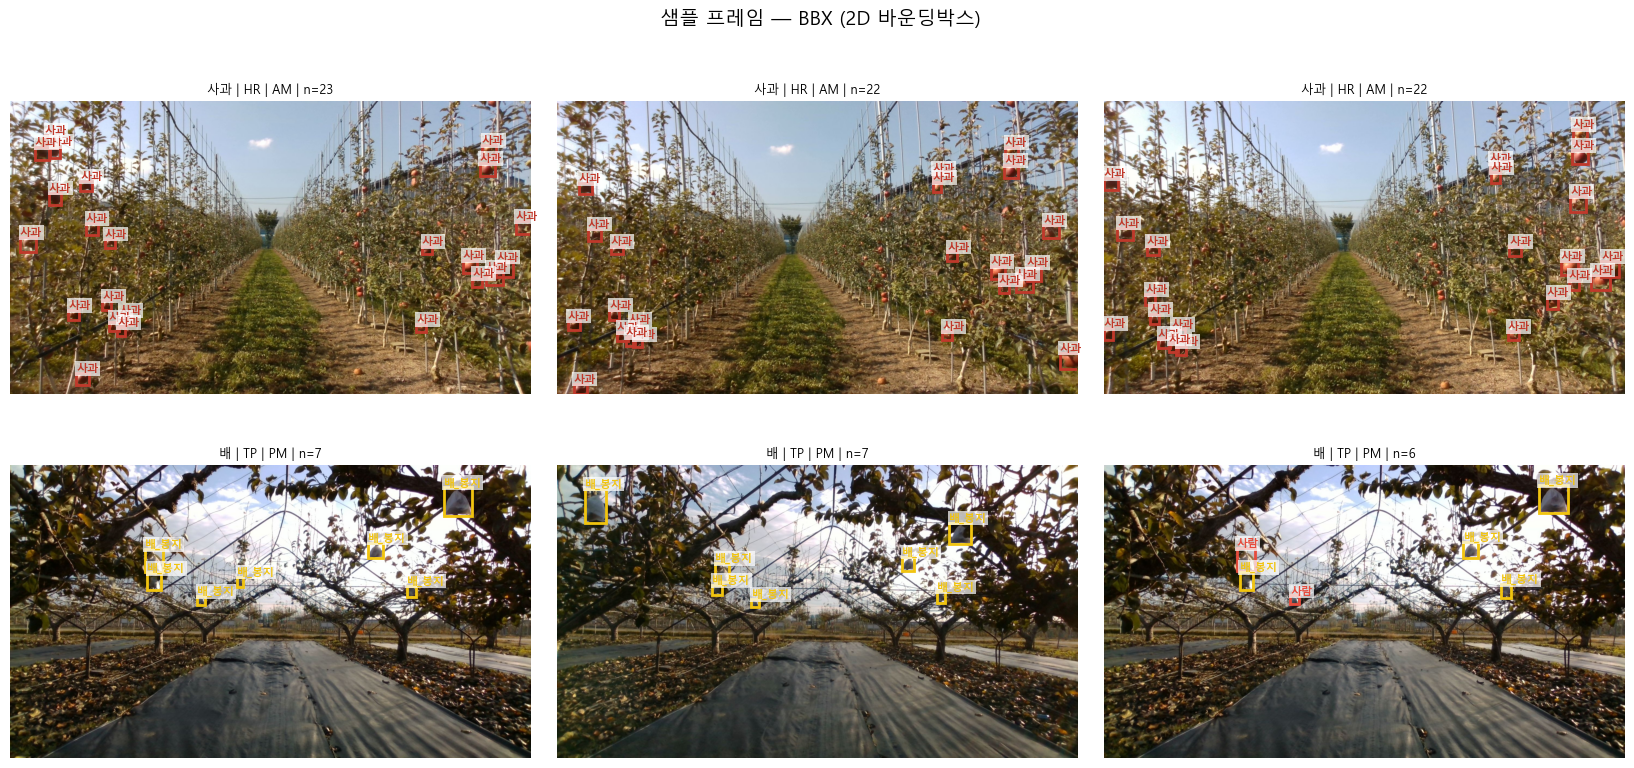

저장: c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)\eda\sample_bbx_annotations.png


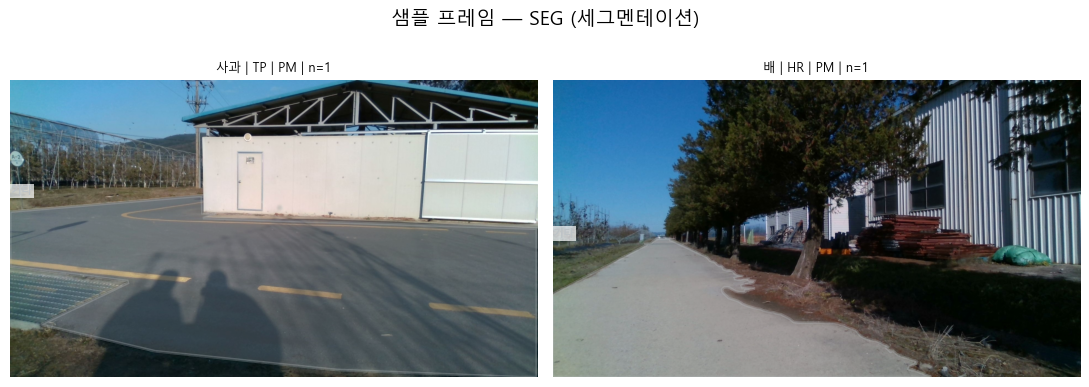

저장: c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)\eda\sample_seg_annotations.png


In [7]:
def draw_bbx(ax, data: dict):
    cats = {c["id"]: c["name"] for c in data.get("categories", [])}
    for ann in data.get("annotations", []):
        bbox = ann.get("bbox")
        if not bbox or len(bbox) != 4:
            continue
        x, y, w, h = bbox
        name = cats.get(ann["category_id"], str(ann["category_id"]))
        color = CLASS_COLORS.get(name, "#2ECC71")
        ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2))
        ax.text(x, max(y - 6, 8), name, color=color, fontsize=8, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))


def draw_seg(ax, data: dict):
    cats = {c["id"]: c["name"] for c in data.get("categories", [])}
    for ann in data.get("annotations", []):
        name = cats.get(ann["category_id"], str(ann["category_id"]))
        color = CLASS_COLORS.get(name, "#2ECC71")
        segs = ann.get("segmentation") or []
        if segs and isinstance(segs[0], (int, float)):
            segs = [segs]
        for poly in segs:
            if not poly or len(poly) < 6:
                continue
            pts = np.array(poly, dtype=float).reshape(-1, 2)
            ax.add_patch(plt.Polygon(pts, fill=True, facecolor=color, alpha=0.25,
                                     edgecolor=color, linewidth=2))
        bbox = ann.get("bbox")
        if bbox and len(bbox) == 4:
            ax.text(bbox[0], max(bbox[1] - 6, 8), name, color=color, fontsize=8, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))


def show_labeled(json_paths, title, drawer, out_name, ncols=3):
    n = len(json_paths)
    if n == 0:
        print(f"{title}: 샘플 없음")
        return
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.2 * nrows))
    fig.suptitle(title, fontsize=14)
    axes_flat = np.atleast_1d(axes).ravel()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    for ax, jp in zip(axes_flat[:n], json_paths):
        data = load_json(jp)
        img_path = json_to_image_path(jp)
        if img_path is None:
            ax.set_title("이미지 없음", fontsize=9)
            ax.axis("off")
            continue
        ax.imshow(Image.open(img_path))
        drawer(ax, data)
        meta = parse_stem_meta(jp.stem)
        n_ann = len(data.get("annotations", []))
        ax.set_title(f"{meta.get('crop')} | {meta.get('platform')} | {meta.get('ampm')} | n={n_ann}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    out_path = EDA_OUT / out_name
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")


# 작물별로 객체가 많은 BBX 프레임 3장씩
bbx_samples = []
for crop in ("사과", "배"):
    sub = df_bbx[df_bbx["crop_folder"] == crop].sort_values("num_annotations", ascending=False)
    bbx_samples.extend(Path(p) for p in sub["json_path"].head(3))

show_labeled(bbx_samples, "샘플 프레임 — BBX (2D 바운딩박스)", draw_bbx, "sample_bbx_annotations.png", ncols=3)

seg_samples = []
for crop in ("사과", "배"):
    sub = df_seg[df_seg["crop_folder"] == crop]
    if len(sub):
        seg_samples.append(Path(sub.iloc[len(sub) // 2]["json_path"]))
show_labeled(seg_samples, "샘플 프레임 — SEG (세그멘테이션)", draw_seg, "sample_seg_annotations.png", ncols=2)

## 5. 주행 시퀀스 분석

,crop,sequence,platform,date,ampm,images,pcd,labels,bbx_objects,cub_objects
0,배,PE_001_HR_20231006_PM_000_000_000,HR,20231006,PM,30,30,"BBX, CUB",30,30
1,배,PE_001_HR_20231010_PM_000_000_000,HR,20231010,PM,30,30,"BBX, CUB",107,55
2,배,PE_001_HR_20231020_PM_000_001_002,HR,20231020,PM,30,30,"BBX, CUB",30,30
3,배,PE_001_HR_20231024_AM_000_000_001,HR,20231024,AM,30,30,"BBX, CUB",30,30
4,배,PE_001_HR_20231111_AM_000_000_000,HR,20231111,AM,30,0,SEG,0,0
5,배,PE_001_HR_20231120_PM_001_000_000,HR,20231120,PM,30,0,SEG,0,0
6,배,PE_001_PC_20231114_AM_000_000_000,PC,20231114,AM,30,30,"BBX, CUB",30,30
7,배,PE_001_PC_20231114_PM_001_002_002,PC,20231114,PM,30,0,BBX,60,0
8,배,PE_001_TP_20231021_AM_000_002_003,TP,20231021,AM,30,30,"BBX, CUB",60,30
9,배,PE_001_TP_20231109_PM_000_002_006,TP,20231109,PM,30,30,"BBX, CUB",30,30


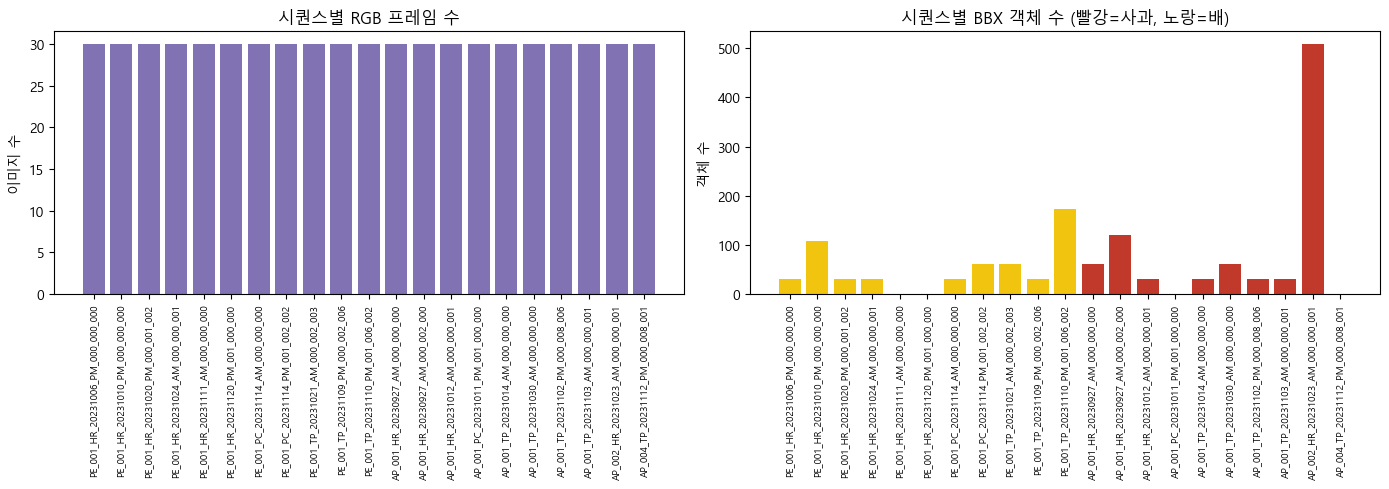

작물별 시퀀스 수: {'배': 11, '사과': 10}
플랫폼별 시퀀스 수: {'HR': 10, 'TP': 8, 'PC': 3}
PCD가 있는 시퀀스: 13 / 21


In [8]:
seq_rows = []
for crop_dir in sorted(p for p in raw_root.iterdir() if p.is_dir()):
    for seq in sorted(s for s in crop_dir.iterdir() if s.is_dir()):
        n_img = len(list((seq / "IMG").glob("*.jpg"))) if (seq / "IMG").exists() else 0
        n_cloud = len(list((seq / "PCD").glob("*.pcd"))) if (seq / "PCD").exists() else 0
        lab_seq = label_root / crop_dir.name / seq.name
        kinds = [d.name for d in sorted(lab_seq.iterdir()) if d.is_dir()] if lab_seq.exists() else []
        meta = parse_stem_meta(seq.name + "_0000")
        n_obj = int(df_ann[(df_ann["sequence"] == seq.name) & (df_ann["kind"] == "BBX")].shape[0])
        n_cub_obj = int(df_cub[df_cub["sequence"] == seq.name].shape[0]) if len(df_cub) else 0
        seq_rows.append({
            "crop": crop_dir.name,
            "sequence": seq.name,
            "platform": meta.get("platform"),
            "date": meta.get("date"),
            "ampm": meta.get("ampm"),
            "images": n_img,
            "pcd": n_cloud,
            "labels": ", ".join(kinds),
            "bbx_objects": n_obj,
            "cub_objects": n_cub_obj,
        })

df_seq = pd.DataFrame(seq_rows)
display(df_seq)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(df_seq)), df_seq["images"], color="#8172B3")
axes[0].set_xticks(range(len(df_seq)), df_seq["sequence"], rotation=90, fontsize=7)
axes[0].set_title("시퀀스별 RGB 프레임 수")
axes[0].set_ylabel("이미지 수")

colors = ["#C0392B" if c == "사과" else "#F1C40F" for c in df_seq["crop"]]
axes[1].bar(range(len(df_seq)), df_seq["bbx_objects"], color=colors)
axes[1].set_xticks(range(len(df_seq)), df_seq["sequence"], rotation=90, fontsize=7)
axes[1].set_title("시퀀스별 BBX 객체 수 (빨강=사과, 노랑=배)")
axes[1].set_ylabel("객체 수")

plt.tight_layout()
plt.savefig(EDA_OUT / "sequence_stats.png", dpi=120, bbox_inches="tight")
plt.show()

print("작물별 시퀀스 수:", df_seq["crop"].value_counts().to_dict())
print("플랫폼별 시퀀스 수:", df_seq["platform"].value_counts().to_dict())
print("PCD가 있는 시퀀스:", int((df_seq["pcd"] > 0).sum()), "/", len(df_seq))

## 6. EDA 요약

| 항목 | 관찰 결과 |
|------|----------|
| 해상도 | FHD **1920×1080** RGB |
| 작물 | 사과(AP) · 배(PE) 시퀀스로 분리 |
| 라벨 | **BBX**(검출) / **SEG**(영역) / **CUB**(3D LiDAR) 가 시퀀스별로 다름 |
| BBX 클래스 | 사과·배_봉지·사람·과수박스 등 동적·작물 객체 중심 |
| SEG 클래스 | 사과나무·배나무·비포장·기타 등 배경·영역 중심 |
| CUB 클래스 | 사람·차량류·사다리·과수박스 등 대형 3D 객체 |
| BBox 형식 | COCO `[x, y, w, h]` 절대좌표 → YOLO 정규화 변환 필요 |
| 3D | CUB는 `position` / `rotation` / `scale` — 2D 학습과 별도 파이프라인 |

<br>

> 다음 단계: BBX JSON을 YOLO `txt`로 변환한 뒤 검출 모델을 학습합니다.

In [9]:
summary = {
    "total_images": int(n_jpg),
    "total_pcd": int(n_pcd),
    "label_files": {"BBX": int(n_bbx), "CUB": int(n_cub), "SEG": int(n_seg)},
    "resolution": "1920x1080",
    "crops": df_bbx["crop"].value_counts().to_dict(),
    "platforms": df_img[df_img["kind"] != "CUB"]["platform"].value_counts().to_dict(),
    "bbx_classes": df_ann[df_ann["kind"] == "BBX"]["class_name"].value_counts().to_dict(),
    "seg_classes": df_ann[df_ann["kind"] == "SEG"]["class_name"].value_counts().to_dict(),
    "cub_classes": df_cub["class_name"].value_counts().to_dict() if len(df_cub) else {},
    "sequences": int(len(df_seq)),
}
summary_path = EDA_OUT / "eda_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f"\n요약 저장: {summary_path}")

{
  "total_images": 630,
  "total_pcd": 390,
  "label_files": {
    "BBX": 510,
    "CUB": 390,
    "SEG": 120
  },
  "resolution": "1920x1080",
  "crops": {
    "배": 270,
    "사과": 240
  },
  "platforms": {
    "HR": 300,
    "TP": 240,
    "PC": 90
  },
  "bbx_classes": {
    "사과": 509,
    "배_봉지": 170,
    "과수박스": 167,
    "사람": 152,
    "창고": 90,
    "운반차": 90,
    "사다리": 60,
    "손수레": 60,
    "방제기": 60,
    "트럭": 60
  },
  "seg_classes": {
    "비포장": 60,
    "기타": 60,
    "배나무": 30,
    "사과나무": 30
  },
  "cub_classes": {
    "사람": 150,
    "과수박스": 115,
    "사다리": 60,
    "손수레": 60,
    "방제기": 60,
    "운반차": 60,
    "트럭": 60
  },
  "sequences": 21
}

요약 저장: c:\MyCursorLab\08_Object_Detection\과수원 내 로봇 주행 데이터(사과, 배 류)\eda\eda_summary.json
